In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/rtl.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# فصل ۸ — یادگیری مبتنی بر نمونه
## درس ۱: الگوریتم K-Nearest Neighbors (KNN)

الگوریتم K-Nearest Neighbors که معمولاً KNN یا kNN نوشته می‌شود، یکی از روشن‌ترین راه‌ها برای دیدن تصمیم‌گیری یک مدل یادگیری ماشین از روی داده است. KNN به‌جای یادگرفتن یک معادلهٔ سراسری در زمان آموزش، نمونه‌های برچسب‌دار را نگه می‌دارد و هنگام رسیدن مشاهدهٔ جدید یک پرسش محلی مطرح می‌کند: کدام مشاهده‌های شناخته‌شده به این نمونه شبیه‌ترند؟ سپس برای نمونهٔ جدید از برچسب‌های اطراف آن استفاده می‌کند. به همین دلیل KNN را یک روش یادگیری مبتنی بر نمونه، مبتنی بر حافظه و ناپارامتری می‌دانند.

این ایدهٔ ساده نکته‌های مهمی در دل خود دارد. یک جریان کاری مفید برای KNN باید معنای شباهت را مشخص کند، تعداد همسایه‌های مناسبی انتخاب کند، ویژگی‌ها را در مقیاس‌های قابل مقایسه قرار دهد، مجموعهٔ آزمون را از تصمیم‌های تنظیم مدل دور نگه دارد و بررسی کند که تصمیم‌های محلی مدل قابل باور هستند یا نه. ممکن است مدل دقت بالایی گزارش کند اما در نزدیکی مرز کلاس‌ها یا برای کلاس‌های کم‌تعداد تصمیم‌های ضعیفی بگیرد. در این نوت‌بوک، KNN را هم از دید مفهومی و هم با scikit-learn پیاده‌سازی می‌کنیم.

این نوت‌بوک از دو مجموعه‌دادهٔ واقعی همین مخزن استفاده می‌کند. مجموعه‌دادهٔ Iris آن‌قدر کوچک است که بتوانیم آن را رسم کنیم و همسایه‌ها را یکی‌یکی ببینیم. مجموعه‌دادهٔ diabetes یک مسئلهٔ دومِ طبقه‌بندی دودویی با متغیرهای بیشتر و مقیاس‌های اندازه‌گیری واقعی‌تر فراهم می‌کند. در طول درس، ویژگی‌های مقیاس‌شده و مقیاس‌نشده را مقایسه می‌کنیم، مقدار $k$ را با اعتبارسنجی متقابل تنظیم می‌کنیم، رأی‌دهی یکنواخت و وزن‌دهی برحسب فاصله را می‌سنجیم، سطح تصمیم دوبعدی می‌کشیم، احتمال‌های پیش‌بینی‌شده را بررسی می‌کنیم و یک مجموعهٔ آزمون مستقل را ارزیابی می‌کنیم.

### هدف‌های یادگیری

در پایان این درس باید بتوانید:

1. توضیح دهید چرا KNN یادگیری مبتنی بر نمونه نام دارد و زمان آموزش را از زمان پیش‌بینی جدا کنید.
2. منطق پیش‌بینی نزدیک‌ترین همسایه را با یک فاصله و یک رأی محلی محاسبه و توضیح دهید.
3. توضیح دهید چرا مقیاس‌بندی ویژگی‌ها فاصلهٔ اقلیدسی را تغییر می‌دهد و برای جلوگیری از نشت داده از Pipeline استفاده کنید.
4. یک طبقه‌بند KNN را با تقسیم آموزش/آزمون بازتولیدپذیر بسازید، آموزش دهید و ارزیابی کنید.
5. به‌جای انتخاب $k$ پس از دیدن امتیاز آزمون، آن را با اعتبارسنجی متقابل انتخاب کنید.
6. رأی‌دهی یکنواخت را با رأی‌دهی وزن‌دار بر حسب فاصله مقایسه و مصالحهٔ آن‌ها را تفسیر کنید.
7. ماتریس درهم‌ریختگی، گزارش طبقه‌بندی، احتمال‌ها و همسایه‌های واقعیِ پشت یک پیش‌بینی را بخوانید.
8. محدودیت‌های عملی مانند پیش‌بینی پرهزینه، بُعد زیاد، ویژگی‌های نامرتبط و نامتوازنی کلاس‌ها را تشخیص دهید.

موضوع تکرارشوندهٔ این درس این است که KNN پارامترهای ریاضی کمی دارد، اما انتخاب‌های مدل‌سازی فراوانی دارد. بنابراین نمایش داده بخشی از مدل است. اگر دو متغیر با واحدهای ناسازگار اندازه‌گیری شوند، اگر یک دسته با عددی دلخواه کدگذاری شود، یا اگر مقادیر گمشده ناهماهنگ مدیریت شوند، رابطهٔ همسایگی می‌تواند بی‌معنا شود. نتیجهٔ خوب KNN با شناخت دقیق داده آغاز می‌شود.

## ۱. چه چیزی KNN را مبتنی بر نمونه می‌کند؟

بسیاری از الگوریتم‌های نظارت‌شده دادهٔ آموزش را با برازش پارامترها خلاصه می‌کنند. رگرسیون خطی ضرایب را برآورد می‌کند، رگرسیون لجستیک یک سطح تصمیم برآورد می‌کند و درخت تصمیم دنباله‌ای از تقسیم‌ها را نگه می‌دارد. KNN راه دیگری برمی‌گزیند. مرحلهٔ آموزش آن عمدتاً ذخیره‌سازی است: بردارهای ویژگی $x_i$ و برچسب‌هایشان $y_i$ را نگه می‌دارد. وقتی نقطهٔ پرس‌وجو $x_*$ می‌رسد، KNN فاصلهٔ آن را تا مشاهده‌های ذخیره‌شده محاسبه می‌کند، نزدیک‌ترین $k$ مشاهده را نگه می‌دارد و برچسب‌های آن‌ها را تجمیع می‌کند.

این رفتار دو پیامد دارد. نخست، KNN را اغلب یادگیرندهٔ تنبل می‌نامند: برازش می‌تواند سریع باشد زیرا برآورد پارامتر چشمگیری انجام نمی‌شود. دوم، پیش‌بینی می‌تواند پرهزینه باشد زیرا در جست‌وجوی ساده، یک پرس‌وجو با تعداد زیادی از سطرهای آموزش مقایسه می‌شود. کتابخانه‌ها می‌توانند بعضی جست‌وجوها را با ساختارهایی مانند KD-tree یا Ball Tree سریع‌تر کنند، اما ایدهٔ اصلی همچنان مقایسهٔ محلی است. در مقابل، یک مدل خطی برازش‌شده معمولاً با یک ضرب داخلی پیش‌بینی می‌کند.

محلی‌بودن همچنین یک نقطهٔ قوت است. KNN می‌تواند شکل‌های پیچیدهٔ کلاس را بدون انتخاب صریح یک فرم تابع خمیده دنبال کند. اگر مثال‌های نزدیک ناحیه‌ای خمیده یا جدا از هم بسازند، رأی می‌تواند با همان ساختار محلی سازگار شود. هزینهٔ این انعطاف، حساسیت است: یک همسایهٔ نویزی، ویژگی با مقیاس نادرست یا نمونهٔ آموزشی غیرنماینده می‌تواند رأی محلی را تغییر دهد. پس KNN به دادهٔ تمیز و نماینده و اعتبارسنجی منظم پاداش می‌دهد.

## ۲. قانون تصمیم KNN

برای مجموعهٔ آموزش $\mathcal{D}=\{(x_i,y_i)\}_{i=1}^{n}$، فاصلهٔ نقطهٔ پرس‌وجو $x_*$ تا هر نقطهٔ آموزش را تعریف می‌کنیم. با فاصلهٔ اقلیدسی داریم:

$$
d(x_*,x_i)=\sqrt{\sum_{j=1}^{p}(x_{*j}-x_{ij})^2}.
$$

فرض کنید $N_k(x_*)$ اندیس‌های $k$ مشاهدهٔ آموزشی نزدیک‌تر را نشان دهد. در طبقه‌بندی، KNN یکنواخت کلاسی را پیش‌بینی می‌کند که بیشترین رأی محلی را دارد:

$$
\hat{y}(x_*)=\operatorname*{arg\,max}_{c\in\mathcal{C}}\sum_{i\in N_k(x_*)}\mathbb{1}(y_i=c).
$$

تابع شاخص $\mathbb{1}(y_i=c)$ در صورتی که همسایهٔ $i$ کلاس $c$ داشته باشد یک و در غیر این صورت صفر است. در نوع وزن‌دار بر حسب فاصله، مشاهده‌های نزدیک‌تر اثر بیشتری می‌گیرند. انتخاب رایج $w_i=1/(d(x_*,x_i)+\epsilon)$ است که در آن $\epsilon$ کوچک از تقسیم بر صفر جلوگیری می‌کند. امتیاز وزن‌دار کلاس به صورت $\sum_{i\in N_k(x_*)}w_i\mathbb{1}(y_i=c)$ می‌شود.

مقدار $k$ همواری را کنترل می‌کند. با $k=1$، هر پیش‌بینی برچسب تنها نزدیک‌ترین همسایه را کپی می‌کند. این کار می‌تواند الگوهای باریک محلی را ببیند، اما به نویز بسیار حساس است. با $k$ بزرگ‌تر، پیش‌بینی روی همسایگی گسترده‌تری میانگین‌گیری می‌شود. این کار واریانس را کم می‌کند ولی ممکن است ناحیه‌های کوچک کلاس را محو و بایاس را زیاد کند. هیچ $k$ برترِ همگانی وجود ندارد؛ مقدار مناسب را با اعتبارسنجی متقابل از دادهٔ آموزش برآورد می‌کنیم.

## ۳. جریان کاری قابل اعتماد برای KNN

پیش از نوشتن کد، نقش‌های داده را جدا کنید. مجموعهٔ آموزش مثال‌هایی را فراهم می‌کند که مدل KNN می‌تواند به‌عنوان همسایه به کار ببرد. اعتبارسنجی متقابل درون مجموعهٔ آموزش، انتخاب‌های نامزد مانند $k$، معیار فاصله و قانون وزن‌دهی را مقایسه می‌کند. مجموعهٔ آزمون تا پایان دست‌نخورده می‌ماند و در آن‌جا یک برآورد نهایی از عملکرد خارج از نمونه می‌دهد. تنظیم تکراری مدل پس از دیدن امتیاز آزمون، مجموعهٔ آزمون را به منبع آموزش دیگری تبدیل و امتیاز نهایی را بیش از حد خوش‌بینانه می‌کند.

پیش‌پردازش نیز باید از همین قانون پیروی کند. یک scaler میانگین و انحراف معیار را از داده یاد می‌گیرد. اگر پیش از تقسیم برازش شود، اطلاعات سطرهای آزمون در نمایش سطرهای آموزش اثر می‌گذارد. شاید این نشت در یک مجموعه‌دادهٔ اسباب‌بازی کوچک باشد، اما همچنان اشتباه مدل‌سازی است. Pipeline در scikit-learn این موضوع را تمیز حل می‌کند: هنگام برازش، scaler فقط از fold آموزش یاد می‌گیرد و KNN مقدارهای تبدیل‌شده را می‌بیند؛ هنگام پیش‌بینی، همان تبدیل یادگرفته‌شده بر سطرهای جدید اعمال می‌شود.

برای طبقه‌بندی، توزیع هدف را نیز بررسی کنید و در صورت امکان تقسیم را stratify کنید. stratification نسبت کلاس‌ها را در زیرمجموعه‌های آموزش و آزمون مشابه نگه می‌دارد. این موضوع به‌ویژه برای داده‌های کوچک یا نامتوازن مهم است، زیرا یک تقسیم تصادفی ممکن است به‌طور اتفاقی نمونه‌های زیادی از یک کلاس را حذف کند.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 20)

## ۴. پیش از مدل‌سازی، مجموعه‌دادهٔ Iris را بررسی کنید

با فایل iris.csv موجود در مخزن شروع می‌کنیم. سطرهای نخست آن چهار اندازه‌گیری عددی را نشان می‌دهند: طول کاسبرگ، عرض کاسبرگ، طول گلبرگ و عرض گلبرگ. ستون classification هدف دسته‌ای است. این بررسی مهم است زیرا KNN به فضای ویژگی عددی نیاز دارد. اگر مجموعه‌داده متن یا دسته‌های اسمی داشت، پیش از محاسبهٔ فاصله به تبدیل مناسبی نیاز داشتیم. از ترتیب سطر به‌عنوان ویژگی استفاده نمی‌کنیم و ستون هدف را نیز وارد ماتریس ویژگی نمی‌کنیم.

Iris سه کلاس گل دارد. اندازه‌گیری‌ها روی مقیاس‌های فیزیکی مشابه، اما نه کاملاً یکسان، هستند. استانداردسازی همچنان پیش‌فرض خوبی برای مدل مبتنی بر فاصله است. این تبدیل هر ویژگی را بر پایهٔ دادهٔ آموزش تقریباً به میانگین صفر و انحراف معیار یک می‌برد. این کار ویژگی‌ها را به‌طور ذاتی هم‌اهمیت نمی‌کند؛ فقط مانع می‌شود یک ویژگی تنها به علت واحد اندازه‌گیری‌اش بر فاصله مسلط شود.

In [3]:
iris_path = Path("../../../Datasets/Classification/iris.csv")
iris_df = pd.read_csv(iris_path)
target_column = "classification"
feature_columns = [column for column in iris_df.columns if column != target_column]
iris_X = iris_df[feature_columns]
iris_y = iris_df[target_column]

display(iris_df.head())
display(iris_df.dtypes.rename("dtype").to_frame())
display(iris_y.value_counts().rename("count").to_frame())

,sepal_length,sepal_width,petal_length,petal_width,classification
0,5.4,3.7,1.5,0.2,Iris-setosa
1,4.8,3.4,1.6,0.2,Iris-setosa
2,4.8,3.0,1.4,0.1,Iris-setosa
3,4.3,3.0,1.1,0.1,Iris-setosa
4,5.8,4.0,1.2,0.2,Iris-setosa


,dtype
sepal_length,float64
sepal_width,float64
petal_length,float64
petal_width,float64
classification,object


,count
classification,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


## ۵. فاصله‌ها و یک رأی نزدیک‌ترین همسایه به‌صورت دستی

فاصلهٔ اقلیدسی نقطهٔ شروع رایج است، اما تنها انتخاب نیست. فاصلهٔ منهتن مجموع اختلاف‌های قدرمطلق مختصات را می‌گیرد، $d_1(x,z)=\sum_j |x_j-z_j|$. فاصلهٔ مینکوفسکی هر دو را تعمیم می‌دهد: $d_q(x,z)=\left(\sum_j |x_j-z_j|^q\right)^{1/q}$. فاصلهٔ اقلیدسی حالت $q=2$ و فاصلهٔ منهتن حالت $q=1$ است. شباهت کسینوسی اغلب برای داده‌های جهت‌محور مانند بردارهای متن مفید است، هرچند پرسش هندسی متفاوتی پاسخ می‌دهد.

یک معیار فاصله مشخص می‌کند چه چیزی شبیه محسوب شود. برای نمونه، فاصلهٔ اقلیدسی فرض می‌کند تفاوت‌های ویژگی‌ها را می‌توان مانند مختصات عمود بر هم ترکیب کرد. این فرض برای متغیرهای عددی اندازه‌گیری‌شده پس از مقیاس‌بندی می‌تواند مناسب باشد، اما برای شناسه‌ها، برچسب‌های ترتیبی یا دسته‌هایی که با 0، 1 و 2 کدگذاری شده‌اند خودبه‌خود مناسب نیست. کد عددی قرمز، سبز و آبی به این معنا نیست که سبز دقیقاً بین دو رنگ دیگر قرار دارد. پس مهندسی ویژگی درست ضروری است.

سلول بعدی یک مثال کوچک دوبعدی می‌سازد. فاصله‌های یک نقطهٔ پرس‌وجو را محاسبه می‌کند، همسایه‌های نامزد را مرتب می‌کند، از میان سه نمونهٔ نزدیک رأی اکثریت می‌گیرد و هندسه را نمایش می‌دهد. این همان منطق KNN است که در این‌جا به‌صورت آشکار دیده می‌شود.

,x1,x2,class,distance_to_query
0,4.0,4.2,Orange,1.664332
1,4.5,3.8,Orange,1.720465
2,1.5,1.8,Blue,1.886796
3,2.0,1.2,Blue,1.941649
4,5.0,4.7,Orange,2.687006
5,1.0,1.0,Blue,2.765863


Predicted class with k=3: Orange


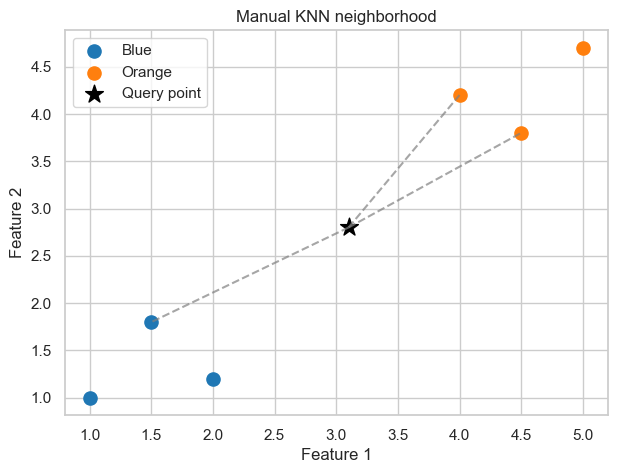

In [4]:
manual_X = np.array([[1.0, 1.0], [1.5, 1.8], [2.0, 1.2], [4.0, 4.2], [4.5, 3.8], [5.0, 4.7]])
manual_y = np.array(["Blue", "Blue", "Blue", "Orange", "Orange", "Orange"])
query_point = np.array([3.1, 2.8])
manual_distances = np.linalg.norm(manual_X - query_point, axis=1)
neighbor_order = np.argsort(manual_distances)
k_manual = 3
nearest_indices = neighbor_order[:k_manual]
manual_vote = pd.Series(manual_y[nearest_indices]).mode().iat[0]
manual_table = pd.DataFrame({"x1": manual_X[:, 0], "x2": manual_X[:, 1], "class": manual_y, "distance_to_query": manual_distances})
display(manual_table.sort_values("distance_to_query").reset_index(drop=True))
print(f"Predicted class with k={k_manual}: {manual_vote}")

fig, ax = plt.subplots(figsize=(7, 5))
for class_name, color in [("Blue", "tab:blue"), ("Orange", "tab:orange")]:
    mask = manual_y == class_name
    ax.scatter(manual_X[mask, 0], manual_X[mask, 1], s=90, color=color, label=class_name)
ax.scatter(query_point[0], query_point[1], s=180, color="black", marker="*", label="Query point")
for index in nearest_indices:
    ax.plot([query_point[0], manual_X[index, 0]], [query_point[1], manual_X[index, 1]], color="gray", linestyle="--", alpha=0.7)
ax.set_title("Manual KNN neighborhood")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend()
plt.show()

## ۶. چرا مقیاس‌بندی برای مدل‌های مبتنی بر فاصله اختیاری نیست

فرض کنید یک ویژگی بین 0 و 1 و ویژگی دیگری بین 0 و 10,000 باشد. در فاصلهٔ اقلیدسی خام، تغییر کوچک در ویژگی با مقیاس بزرگ می‌تواند از تفاوت بزرگ در ویژگی با مقیاس کوچک اثرگذارتر باشد. در این حالت مدل طوری رفتار می‌کند که گویی ویژگی بزرگ‌تر ذاتاً مهم‌تر است، حتی اگر مقیاس فقط حاصل واحد اندازه‌گیری باشد. StandardScaler با تبدیل یک ویژگی آموزشی $x_j$ به $z_j=(x_j-\mu_j)/\sigma_j$ این مسئله را برطرف می‌کند.

این تبدیل باید در هر fold آموزش یاد گرفته شود. در مقایسهٔ زیر، عمداً عرض گلبرگ را در 100 ضرب می‌کنیم تا ناسازگاری واحد مصنوعی بسازیم. طبقه‌بند مقیاس‌نشده آن مختصات تغییرکرده را غالب می‌بیند. Pipeline مقیاس‌شده نمایش قابل مقایسه را بازمی‌گرداند. امتیاز دقیق ممکن است با یک تقسیم تغییر کند، اما درس ساختاری است: معیار فاصله تنها نسبت به مقیاس مختصاتش معنا دارد.

مقیاس‌بندی درمان ویژگی نامرتبط نیست. یک ویژگی نویزی تصادفی که استاندارد شده باشد همچنان به محاسبهٔ فاصله نویز می‌افزاید. انتخاب ویژگی، دانش دامنه و اعتبارسنجی همچنان مهم‌اند. مقیاس‌بندی فقط تضمین می‌کند واحدهای عددی به‌طور پنهان وزن‌ها را برای ما انتخاب نکنند.

In [5]:
scale_demo_X = iris_X.copy()
scale_demo_X["petal_width"] = scale_demo_X["petal_width"] * 100
scale_demo_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
unscaled_model = KNeighborsClassifier(n_neighbors=5)
scaled_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
unscaled_scores = cross_val_score(unscaled_model, scale_demo_X, iris_y, cv=scale_demo_cv, scoring="accuracy", error_score="raise")
scaled_scores = cross_val_score(scaled_model, scale_demo_X, iris_y, cv=scale_demo_cv, scoring="accuracy", error_score="raise")
scale_comparison = pd.DataFrame({"model": ["Unscaled KNN", "Scaled KNN pipeline"], "mean_accuracy": [unscaled_scores.mean(), scaled_scores.mean()], "std_accuracy": [unscaled_scores.std(), scaled_scores.std()]})
display(scale_comparison.round(3))

,model,mean_accuracy,std_accuracy
0,Unscaled KNN,0.953,0.034
1,Scaled KNN pipeline,0.967,0.037


## ۷. یک طبقه‌بند پایهٔ KNN برازش دهید

اکنون یک مجموعهٔ آزمون کنارگذاشته‌شده می‌سازیم. مدل پایه از $k=5$، فاصلهٔ اقلیدسی و رأی‌دهی یکنواخت استفاده می‌کند. این مدل عمداً یک baseline است، نه ادعایی مبنی بر بهینه بودن پنج همسایه. مدل پایه یک نقطهٔ مرجع می‌دهد، مسیر داده و پیش‌پردازش را بررسی می‌کند و مدلی برازش‌شده برای بازرسی‌های بعدی فراهم می‌سازد. تقسیم به‌صورت stratified انجام می‌شود تا هر سه کلاس Iris در هر دو زیرمجموعه حضور داشته باشند.

به استفاده از Pipeline دقت کنید. فراخوانی fit روی pipeline، scaler را از X_train یاد می‌گیرد و سپس KNN را روی سطرهای آموزشیِ تبدیل‌شده برازش می‌دهد. فراخوانی predict روی X_test همان مقیاس‌بندی یادگرفته‌شده را اعمال و سپس همسایه‌ها را می‌پرسد. این الگو کوتاه، بازتولیدپذیر و در اعتبارسنجی متقابل ایمن است. همچنین استقرار را کم‌خطاتر می‌کند، زیرا پیش‌پردازش و پیش‌بینی کنار هم حرکت می‌کنند.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(iris_X, iris_y, test_size=0.25, stratify=iris_y, random_state=RANDOM_STATE)
baseline_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, weights="uniform"))
baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_report = pd.DataFrame(classification_report(y_test, baseline_predictions, output_dict=True, zero_division=0)).T
print(f"Baseline test accuracy: {baseline_accuracy:.3f}")
display(baseline_report.round(3))

Baseline test accuracy: 0.921


,precision,recall,f1-score,support
Iris-setosa,1.000,1.000,1.000,12.000
Iris-versicolor,0.812,1.000,0.897,13.000
Iris-virginica,1.000,0.769,0.870,13.000
accuracy,0.921,0.921,0.921,0.921
macro avg,0.938,0.923,0.922,38.000
weighted avg,0.936,0.921,0.920,38.000


## ۸. بیش از یک عدد را ارزیابی کنید

دقت نسبت پیش‌بینی‌های درست است: $\text{accuracy}=\frac{1}{m}\sum_{i=1}^{m}\mathbb{1}(\hat{y}_i=y_i)$. وقتی کلاس‌ها نسبتاً متوازن‌اند و همهٔ خطاها هزینهٔ مشابهی دارند، معیار مفیدی است. با این حال دقت نشان نمی‌دهد کدام کلاس‌ها با هم اشتباه می‌شوند. ماتریس درهم‌ریختگی کلاس‌های واقعی و پیش‌بینی‌شده را روی دو محور می‌گذارد و الگوهای خطا را آشکار می‌کند.

گزارش طبقه‌بندی برای هر کلاس precision، recall و F1 را اضافه می‌کند. Precision می‌پرسد یک کلاسِ پیش‌بینی‌شده چند بار درست بوده است. Recall می‌پرسد چند عضو واقعی آن کلاس پیدا شده‌اند. F1 میانگین هارمونیک این دو است: $F1=2\frac{\text{precision}\cdot\text{recall}}{\text{precision}+\text{recall}}$. در مسئلهٔ غربالگری پزشکی، recall پایین برای کلاس مثبت می‌تواند از کاهش اندک دقت کلی جدی‌تر باشد. معیارها باید با مسئلهٔ تصمیم هم‌خوان باشند، نه فقط با راحتی یک امتیاز منفرد.

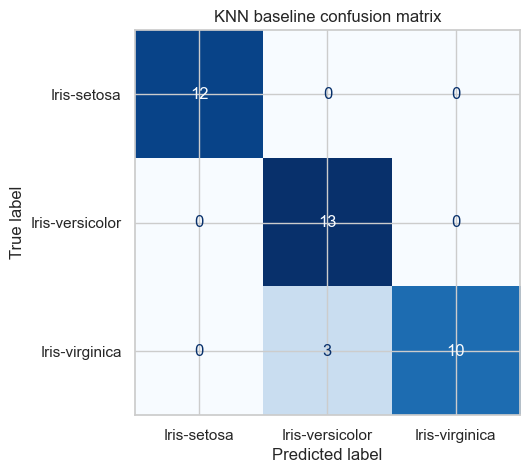

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, baseline_predictions, display_labels=baseline_model.classes_, cmap="Blues", colorbar=False, ax=ax)
ax.set_title("KNN baseline confusion matrix")
plt.show()

## ۹. انتخاب $k$ با اعتبارسنجی متقابل

انتخاب $k$ از روی امتیاز آزمون باعث overfit شدن روی مجموعهٔ آزمون می‌شود. در عوض، روی زیرمجموعهٔ آموزش از اعتبارسنجی متقابل stratified پنج‌تایی استفاده می‌کنیم. هر مقدار نامزد پنج بار ارزیابی می‌شود و هر بار fold متفاوتی نقش دادهٔ اعتبارسنجی را دارد. میانگین امتیاز اعتبارسنجی تخمینی از تعمیم آن پیکربندی با دادهٔ آموزش موجود می‌دهد. مجموعهٔ آزمون در طول این انتخاب دست‌نخورده باقی می‌ماند.

منحنی امتیاز به‌ندرت کاملاً هموار است. مجموعه‌دادهٔ کوچک تغییرپذیری نمونه‌گیری دارد و مقدارهای نزدیک $k$ ممکن است از نظر آماری قابل تشخیص نباشند. مقداری را ترجیح دهید که رقابتی و پایدار است، نه این‌که تفاوت بسیار کوچک را کشف علمی تلقی کنید. در طبقه‌بندی دودویی، مقدارهای فرد اغلب مفیدند زیرا رأی مساوی را کمتر می‌کنند، اما مسئله‌های چندکلاسه و رأی‌دهی وزن‌دار همچنان می‌توانند تساوی داشته باشند. scikit-learn تساوی‌ها را به‌شکل قطعی مدیریت می‌کند، ولی بهتر است اعتبارسنجی را آگاهانه طراحی کنیم تا به یک قانون دلخواه تکیه نکنیم.

مقدارهای 1 تا 25 را بررسی می‌کنیم. این بازه برای این مجموعه‌دادهٔ کوچک عمداً محدود است. در مجموعهٔ آموزش بزرگ‌تر، بازه و راهبرد جست‌وجو ممکن است گسترده‌تر باشد؛ با این حال امتحان همهٔ مقدارهای ممکن معمولاً لازم نیست.

,k,mean_validation_accuracy,std_validation_accuracy
15,16,0.982,0.022
11,12,0.974,0.035
13,14,0.974,0.035
12,13,0.974,0.035
7,8,0.974,0.035
5,6,0.973,0.036
2,3,0.973,0.022
6,7,0.965,0.051


Selected k from cross-validation: 16


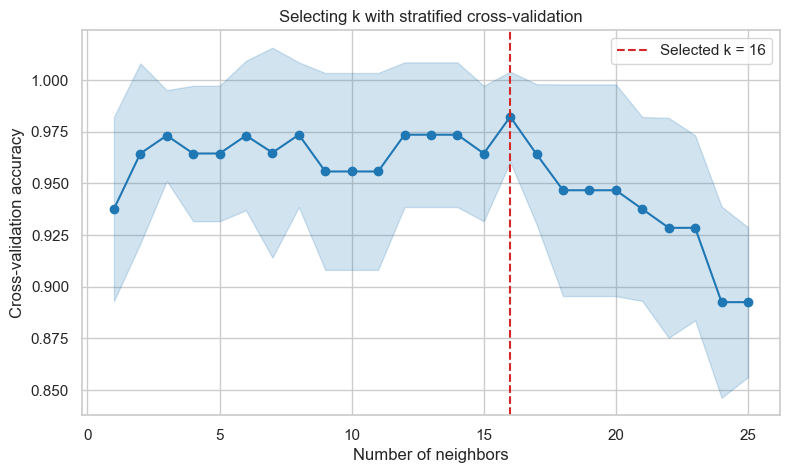

In [8]:
selection_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
k_values = list(range(1, 26))
validation_means = []
validation_stds = []
for k_value in k_values:
    candidate_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k_value, weights="uniform"))
    candidate_scores = cross_val_score(candidate_model, X_train, y_train, cv=selection_cv, scoring="accuracy", error_score="raise")
    validation_means.append(candidate_scores.mean())
    validation_stds.append(candidate_scores.std())
k_results = pd.DataFrame({"k": k_values, "mean_validation_accuracy": validation_means, "std_validation_accuracy": validation_stds})
best_k = int(k_results.loc[k_results["mean_validation_accuracy"].idxmax(), "k"])
display(k_results.sort_values("mean_validation_accuracy", ascending=False).head(8).round(3))
print(f"Selected k from cross-validation: {best_k}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_results["k"], k_results["mean_validation_accuracy"], marker="o", color="tab:blue")
ax.fill_between(k_results["k"], k_results["mean_validation_accuracy"] - k_results["std_validation_accuracy"], k_results["mean_validation_accuracy"] + k_results["std_validation_accuracy"], alpha=0.2, color="tab:blue")
ax.axvline(best_k, color="tab:red", linestyle="--", label=f"Selected k = {best_k}")
ax.set_xlabel("Number of neighbors")
ax.set_ylabel("Cross-validation accuracy")
ax.set_title("Selecting k with stratified cross-validation")
ax.legend()
plt.show()

## ۱۰. همسایه‌های یکنواخت در برابر وزن‌دار برحسب فاصله

KNN یکنواخت به هر همسایهٔ انتخاب‌شده یک رأی می‌دهد. این روش ساده است و وقتی تراکم محلی قابل اعتماد باشد اغلب عملکرد خوبی دارد. وزن‌دهی بر اساس فاصله به مثال‌های نزدیک‌تر اثر بیشتری می‌دهد؛ بنابراین ممکن است نقطهٔ پرس‌وجویی که بسیار نزدیک یک نمونهٔ آموزش است با چند مشاهدهٔ دورتر نادیده گرفته نشود. در scikit-learn، weights="distance" رفتار معکوس فاصله را به‌طور خودکار اعمال می‌کند.

وزن‌دهی بر حسب فاصله خودبه‌خود برتر نیست. اگر ویژگی‌ها نویزی یا فاصله‌ها ناپایدار باشند، تأکید بر نزدیک‌ترین نقطه می‌تواند حساسیت به نویز را بالا ببرد. همچنین مقیاس‌بندی درست را مهم‌تر می‌کند. در مقایسهٔ بعدی، $k$ انتخاب‌شده ثابت می‌ماند و میانگین دقت اعتبارسنجی متقابل هر دو قانون رأی برآورد می‌شود. نتیجه را شاهدی برای همین داده و تقسیم می‌دانیم، نه رتبه‌بندی همگانی.

In [9]:
weight_rows = []
for weight_rule in ["uniform", "distance"]:
    weight_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k, weights=weight_rule))
    weight_scores = cross_val_score(weight_model, X_train, y_train, cv=selection_cv, scoring="accuracy", error_score="raise")
    weight_rows.append({"weights": weight_rule, "mean_validation_accuracy": weight_scores.mean(), "std_validation_accuracy": weight_scores.std()})
weight_results = pd.DataFrame(weight_rows)
display(weight_results.round(3))

,weights,mean_validation_accuracy,std_validation_accuracy
0,uniform,0.982,0.022
1,distance,0.974,0.035


## ۱۱. یک سطح تصمیم محلی را رسم کنید

یک مشاهدهٔ کامل Iris چهار ویژگی دارد و بنابراین هندسهٔ تصمیم آن در چهار بُعد قرار می‌گیرد. نمی‌توانیم آن را مستقیماً روی صفحه رسم کنیم. در عوض، نمودار بعدی فقط از طول و عرض گلبرگ استفاده می‌کند. این یک تصویرسازی جداگانه با دو ویژگی است، نه همان مدلی که برای ارزیابی آزمون با چهار ویژگی به کار رفت. پس‌زمینهٔ رنگی کلاس پیش‌بینی‌شده در هر نقطه از صفحهٔ دوبعدی را نشان می‌دهد و نقاط، گل‌های مشاهده‌شده‌اند.

مرزهای KNN می‌توانند نامنظم باشند، زیرا با مشاهده‌های نزدیک شکل می‌گیرند. مقدارهای کوچک $k$ معمولاً ناحیه‌های پیچیده‌ای می‌سازند که به نقطه‌های منفرد نزدیک‌اند. مقدارهای بزرگ‌تر $k$ ناحیه‌های هموارتر می‌سازند. این رفتار دیداری، بیان دیگری از مصالحهٔ بایاس-واریانس است. مرز پیچیده می‌تواند جزئیات محلی را توصیف کند، اما ممکن است نویز نمونه‌گیری را نیز دنبال کند.

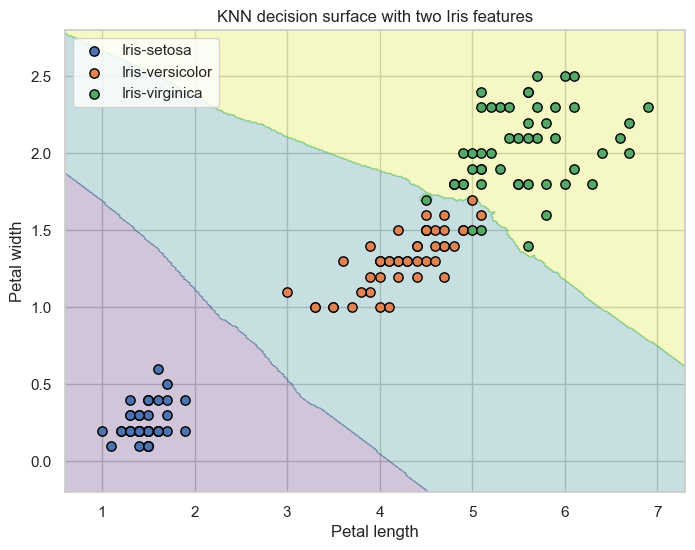

In [10]:
boundary_features = iris_df[["petal_length", "petal_width"]].to_numpy()
boundary_encoder = LabelEncoder()
boundary_labels = boundary_encoder.fit_transform(iris_y)
boundary_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k, weights="distance"))
boundary_model.fit(boundary_features, boundary_labels)
x_min, x_max = boundary_features[:, 0].min() - 0.4, boundary_features[:, 0].max() + 0.4
y_min, y_max = boundary_features[:, 1].min() - 0.3, boundary_features[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = boundary_model.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, zz, alpha=0.25, cmap="viridis")
for class_index, class_name in enumerate(boundary_encoder.classes_):
    mask = boundary_labels == class_index
    ax.scatter(boundary_features[mask, 0], boundary_features[mask, 1], s=45, label=class_name, edgecolor="black")
ax.set_xlabel("Petal length")
ax.set_ylabel("Petal width")
ax.set_title("KNN decision surface with two Iris features")
ax.legend()
plt.show()

## ۱۲. همسایه‌ها و احتمال‌ها را بررسی کنید

یکی از ویژگی‌های جذاب KNN این است که می‌توان یک پیش‌بینی را تا مثال‌های عینی دنبال کرد. برای یک سطر پرس‌وجوی مشخص، می‌توانیم بپرسیم کدام سطرهای آموزش انتخاب شده‌اند و پس از مقیاس‌بندی چه فاصله‌ای داشته‌اند. این توضیح علّی نیست: یک مثال نزدیک ثابت نمی‌کند چرا یک گل به کلاسی تعلق دارد. با این حال، توضیح محلی مفیدی از قانون تصمیم مدل است.

احتمال‌های کلاس در KNN معمولاً نسبت رأی محلی هستند. در وزن‌دهی یکنواخت، اگر چهار همسایه از پنج همسایه متعلق به یک کلاس باشند، احتمال آن کلاس 0.8 می‌شود. در وزن‌دهی بر اساس فاصله، نسبت‌ها از رأی‌های وزن‌دار ساخته می‌شوند. این مقدارها برای رتبه‌بندی عدم قطعیت مفیدند، اما نباید خودبه‌خود آن‌ها را احتمال‌های کالیبره‌شدهٔ دنیای واقعی دانست. به‌خصوص وقتی احتمال‌ها به‌جای صرفاً برچسب کلاس تصمیم می‌سازند، کالیبراسیون باید جداگانه ارزیابی شود.

In [11]:
selected_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k, weights="distance"))
selected_model.fit(X_train, y_train)
query_row = X_test.iloc[[0]]
query_scaled = selected_model.named_steps["standardscaler"].transform(query_row)
neighbor_distances, neighbor_indices = selected_model.named_steps["kneighborsclassifier"].kneighbors(query_scaled, n_neighbors=best_k)
neighbor_table = X_train.iloc[neighbor_indices[0]].copy()
neighbor_table["true_class"] = y_train.iloc[neighbor_indices[0]].to_numpy()
neighbor_table["scaled_distance"] = neighbor_distances[0]
class_probabilities = selected_model.predict_proba(query_row)[0]
probability_table = pd.DataFrame({"class": selected_model.classes_, "predicted_probability": class_probabilities})
display(query_row.assign(predicted_class=selected_model.predict(query_row)))
display(neighbor_table.sort_values("scaled_distance").round(3))
display(probability_table.sort_values("predicted_probability", ascending=False).round(3))

,sepal_length,sepal_width,petal_length,petal_width,predicted_class
42,4.4,3.2,1.3,0.2,Iris-setosa


,sepal_length,sepal_width,petal_length,petal_width,true_class,scaled_distance
47,4.6,3.2,1.4,0.2,Iris-setosa,0.247
13,4.6,3.1,1.5,0.2,Iris-setosa,0.346
12,4.7,3.2,1.3,0.2,Iris-setosa,0.360
29,4.7,3.2,1.6,0.2,Iris-setosa,0.398
3,4.3,3.0,1.1,0.1,Iris-setosa,0.491
16,4.6,3.4,1.4,0.3,Iris-setosa,0.524
30,4.8,3.1,1.6,0.2,Iris-setosa,0.556
34,4.9,3.1,1.5,0.1,Iris-setosa,0.663
19,4.9,3.1,1.5,0.1,Iris-setosa,0.663
37,4.9,3.1,1.5,0.1,Iris-setosa,0.663


,class,predicted_probability
0,Iris-setosa,1.0
1,Iris-versicolor,0.0
2,Iris-virginica,0.0


## ۱۳. یک مجموعه‌دادهٔ واقعی دوم: طبقه‌بندی diabetes

یک مجموعه‌دادهٔ واحد می‌تواند مدل را ساده‌تر از واقعیت نشان دهد. بنابراین جریان کاری اصلی را با diabetes.csv موجود در مخزن تکرار می‌کنیم. سطرهای نخست آن متغیرهای عددی مرتبط با سلامت مانند Glucose، BMI، Age و Insulin را نشان می‌دهند و classification هدف دودویی است. متغیرها دامنه‌های بسیار متفاوتی دارند و همین مقیاس‌بندی را مهم‌تر می‌کند. برای مثال، DiabetesPedigreeFunction از نظر عددی بسیار کوچک‌تر از Glucose است، هرچند هر دو ممکن است سیگنال مفیدی داشته باشند.

این یک مدل بالینی نیست و نباید برای تشخیص استفاده شود. این فقط نمونه‌ای برای برنامه‌نویسی و ارزیابی است. بعضی مجموعه‌داده‌های سلامت مقدار صفر دارند که ممکن است به‌جای صفر واقعی، اندازه‌گیری گمشده را نشان دهد. تحلیل تولیدی باید گردآوری داده، گم‌شدگی، انصاف، کالیبراسیون، هزینه‌های بالینی و اعتبارسنجی بیرونی را بررسی کند. در این‌جا نشان می‌دهیم همان الگوی Pipeline با ساختار هدف متفاوت نیز کار می‌کند و balanced accuracy را در کنار دقت معمولی می‌افزاییم.

Balanced accuracy میانگین recall کلاس‌هاست. این معیار زمانی مفید است که یک کلاس پرتکرارتر باشد، زیرا طبقه‌بندی که فقط کلاس اکثریت را پیش‌بینی می‌کند ممکن است با دقت معمولی به‌شکل فریبنده‌ای موفق دیده شود.

In [12]:
diabetes_path = Path("../../../Datasets/Classification/diabetes.csv")
diabetes_df = pd.read_csv(diabetes_path)
diabetes_target = "classification"
diabetes_features = [column for column in diabetes_df.columns if column != diabetes_target]
diabetes_X = diabetes_df[diabetes_features]
diabetes_y = diabetes_df[diabetes_target]

display(diabetes_df.head())
display(diabetes_df.dtypes.rename("dtype").to_frame())
display(diabetes_y.value_counts().rename("count").to_frame())

diabetes_X_train, diabetes_X_test, diabetes_y_train, diabetes_y_test = train_test_split(diabetes_X, diabetes_y, test_size=0.25, stratify=diabetes_y, random_state=RANDOM_STATE)
diabetes_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=9, weights="distance"))
diabetes_model.fit(diabetes_X_train, diabetes_y_train)
diabetes_predictions = diabetes_model.predict(diabetes_X_test)
diabetes_metrics = pd.DataFrame({"metric": ["accuracy", "balanced_accuracy"], "value": [accuracy_score(diabetes_y_test, diabetes_predictions), balanced_accuracy_score(diabetes_y_test, diabetes_predictions)]})
display(diabetes_metrics.round(3))
display(pd.DataFrame(classification_report(diabetes_y_test, diabetes_predictions, output_dict=True, zero_division=0)).T.round(3))

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,classification
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non-Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non-Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic


,dtype
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
classification,object


,count
classification,
Non-Diabetic,500
Diabetic,268


,metric,value
0,accuracy,0.740
1,balanced_accuracy,0.696


,precision,recall,f1-score,support
Diabetic,0.649,0.552,0.597,67.00
Non-Diabetic,0.778,0.840,0.808,125.00
accuracy,0.740,0.740,0.740,0.74
macro avg,0.713,0.696,0.702,192.00
weighted avg,0.733,0.740,0.734,192.00


## ۱۴. آیا دادهٔ آموزشی بیشتر کمک می‌کند؟

منحنی یادگیری عملکرد اعتبارسنجی را وقتی مقدار دادهٔ آموزش رشد می‌کند برآورد می‌کند. این منحنی به تمایز دو وضعیت کلی کمک می‌کند. اگر امتیازهای آموزش و اعتبارسنجی هر دو پایین و نزدیک به هم باشند، نمایش فعلی یا مدل ممکن است بایاس بالا داشته باشد. اگر امتیاز آموزش بسیار بالاتر از اعتبارسنجی باشد، مدل ممکن است واریانس بالا یا دادهٔ ناکافی داشته باشد. KNN با $k$ بسیار کوچک نمونهٔ رایجی است که در آن حساسیت محلی می‌تواند شکاف بسازد.

نمودار زیر از پیکربندی انتخاب‌شدهٔ Iris و چند تقسیم اعتبارسنجی متقابل استفاده می‌کند. این نمودار ابزار تشخیصی است، نه تضمین. منحنی‌ها با نمونه‌ها تغییر می‌کنند و مجموعه‌دادهٔ کوچک عدم قطعیت بزرگی تولید می‌کند. با وجود این، عادت مفیدی را تشویق می‌کند: فرض نکنید تغییر hyperparameter تنها راه بهبود است. دادهٔ بهتر، مثال‌های نماینده‌تر، ویژگی‌های با انتخاب دقیق یا خانوادهٔ مدل متفاوت ممکن است ارزشمندتر باشند.

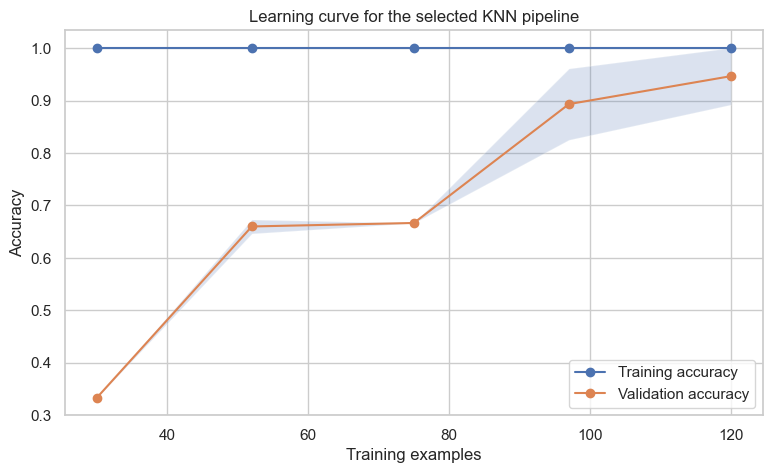

In [13]:
curve_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k, weights="distance"))
curve_sizes, curve_train_scores, curve_validation_scores = learning_curve(curve_model, iris_X, iris_y, cv=selection_cv, train_sizes=np.linspace(0.25, 1.0, 5), scoring="accuracy", error_score="raise")
curve_train_mean = curve_train_scores.mean(axis=1)
curve_validation_mean = curve_validation_scores.mean(axis=1)
curve_validation_std = curve_validation_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(curve_sizes, curve_train_mean, marker="o", label="Training accuracy")
ax.plot(curve_sizes, curve_validation_mean, marker="o", label="Validation accuracy")
ax.fill_between(curve_sizes, curve_validation_mean - curve_validation_std, curve_validation_mean + curve_validation_std, alpha=0.2)
ax.set_xlabel("Training examples")
ax.set_ylabel("Accuracy")
ax.set_title("Learning curve for the selected KNN pipeline")
ax.legend()
plt.show()

## ۱۵. محدودیت‌های عملی و فهرست بررسی مدل‌سازی

KNN به‌عنوان مدل پایه و مدل محلی شهودی قدرتمند است، اما محدودیت‌هایی دارد. پیش‌بینی به جست‌وجو میان مشاهده‌های ذخیره‌شده نیاز دارد، پس زمان پاسخ و حافظه می‌توانند با مجموعهٔ آموزش رشد کنند. روش‌های جست‌وجوی درختی ممکن است در بُعد کم تا متوسط کمک کنند، اما در بُعد زیاد حتی ساختارهای کارآمد نیز مزیت خود را از دست می‌دهند. این با نفرین بُعد مرتبط است: با افزایش بُعد، نقطه‌ها به‌طور فزاینده‌ای فاصله‌های مشابهی دارند و عبارت نزدیک‌ترین همسایه اطلاعات کمتری می‌دهد.

ویژگی‌های نامرتبط این مسئله را بدتر می‌کنند، زیرا هر مختصات افزوده فاصله را تغییر می‌دهد. ویژگی‌های هم‌بسته نیز می‌توانند اثر بیش از حد بگیرند، چون اطلاعات آن‌ها عملاً دوبار شمرده می‌شود. مقادیر گمشده به راهبردی آگاهانه نیاز دارند؛ رفتار با اندازه‌گیری گمشده به‌عنوان صفر می‌تواند شباهت مصنوعی بسازد. متغیرهای دسته‌ای به کدگذاری و اغلب طراحی فاصلهٔ متناسب با معنای خود نیاز دارند. نقاط پرت می‌توانند همسایگی محلی را مخدوش کنند و نامتوازنی کلاس می‌تواند رأی اکثریت را از کلاس اقلیت دور کند.

پیش از اعتماد به نتیجهٔ KNN از این فهرست استفاده کنید:

1. مسیر فایل، ستون هدف، نوع ویژگی‌ها و سطرهای نخست داده را بررسی کنید.
2. شناسه‌ها و متغیرهای دارای نشت هدف را از ویژگی‌ها حذف کنید.
3. پیش از برازش هر scaler، imputer یا encoder داده را تقسیم کنید.
4. پیش‌پردازش و KNN را در یک Pipeline قرار دهید.
5. در صورت امکان برای طبقه‌بندی از اعتبارسنجی متقابل stratified استفاده کنید.
6. $k$، معیار و وزن‌ها را فقط روی foldهای آموزش تنظیم کنید.
7. فقط دقت را نبینید و معیارهای هر کلاس را بررسی کنید.
8. چند مجموعهٔ همسایه و خطاهای شگفت‌انگیز را بازرسی کنید.
9. پیش از استقرار، هزینهٔ زمان پیش‌بینی و حافظه را در نظر بگیرید.
10. داده‌ای را اعتبارسنجی کنید که جمعیت واقعی و هزینه‌های تصمیم واقعی را نمایندگی می‌کند.

این گام‌ها تشریفات ویژهٔ KNN نیستند؛ عادت‌هایی هستند که به تقریباً همهٔ روش‌های یادگیری نظارت‌شده منتقل می‌شوند.

## ۱۶. تمرین‌ها

1. معیار فاصلهٔ Iris را با تنظیم p=1 در KNeighborsClassifier به فاصلهٔ منهتن تغییر دهید. دقت اعتبارسنجی متقابل و سطح تصمیم دوبعدی را مقایسه کنید.
2. هر بار یکی از ویژگی‌های Iris را حذف کنید. کدام اندازه‌گیری برای این تقسیم مفیدتر به نظر می‌رسد؟ توضیح دهید چرا نتیجه‌گیری از مجموعه‌دادهٔ کوچک باید محتاطانه باشد.
3. یک ستون عددی تصادفی به iris_X اضافه، آن را وارد Pipeline کنید و امتیازهای اعتبارسنجی را مقایسه کنید. این کار دربارهٔ ابعاد نامرتبط چه نشان می‌دهد؟
4. روی دادهٔ diabetes، $k$ را با یک حلقهٔ اعتبارسنجی متقابل فقط روی آموزش تنظیم کنید و معیاری انتخاب کنید که برای مسئلهٔ غربالگری مناسب باشد. دقت و balanced accuracy را مقایسه کنید.
5. چند سطر آزمون را که مدل KNN انتخاب‌شده در آن‌ها اشتباه کرده است پیدا کنید. همسایه‌های آن‌ها را بررسی و مشخص کنید آیا پیش‌بینی مبهم به نظر می‌رسد یا الگوی ویژگی گمراه‌کننده بوده است.

### جمع‌بندی

KNN از شواهد محلی پیش‌بینی می‌کند: مشاهده‌ها را به ویژگی تبدیل کنید، فاصله را بسنجید، همسایه‌ها را انتخاب کنید و برچسب‌هایشان را تجمیع کنید. سادگی ظاهری آن فرض‌هایش را آشکار می‌کند. مقیاس مهم است، طراحی ویژگی مهم است، اعتبارسنجی مهم است و شواهد محلی را می‌توان مستقیم بررسی کرد. برای جلوگیری از نشت از pipeline استفاده کردیم، برای انتخاب $k$ اعتبارسنجی متقابل به کار بردیم، چند معیار را برای ارزیابی پیش‌بینی‌ها دیدیم و روش را روی دو مجموعه‌دادهٔ مخزن اجرا کردیم. درس‌های بعدی بر این پایه بنا می‌شوند و انتخاب نظام‌مندتر $k$ و اثر معیارهای فاصله و قانون‌های وزن‌دهی بر مدل KNN را بررسی می‌کنند.